# IEEE ML Challenge – Device Fault Detection

Author: Bhumi   

## Objective

The objective of this challenge is to predict whether a device is operating normally or experiencing a faulty condition based on 47 numerical features.

Target Variable:

- Class = 0 → Device operating normally  
- Class = 1 → Device exhibiting faulty behavior

This is a **binary classification problem** involving tabular numerical data.

In [ ]:
## Library Imports

The following libraries are used in this notebook:

- **Pandas / NumPy** → data manipulation and numerical computation
- **Scikit-learn** → model validation and evaluation
- **XGBoost** → gradient boosting model for classification
- **Seaborn / Matplotlib** → data visualization

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

## Dataset Overview

The dataset contains **47 numerical features** labeled F01–F47.

These values represent internal measurements captured by a monitoring system during device operation.

The training dataset includes a target variable **Class**, indicating whether the device is normal or faulty.

In [3]:
train = pd.read_csv("TRAIN.csv")
test = pd.read_csv("TEST.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (43776, 48)
Test Shape: (10944, 48)


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


## Data Inspection

All features are numerical and there are no missing values observed in the dataset.

This simplifies preprocessing because no imputation or encoding is required.

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F01     43776 non-null  float64
 1   F02     43776 non-null  float64
 2   F03     43776 non-null  float64
 3   F04     43776 non-null  float64
 4   F05     43776 non-null  float64
 5   F06     43776 non-null  float64
 6   F07     43776 non-null  float64
 7   F08     43776 non-null  float64
 8   F09     43776 non-null  float64
 9   F10     43776 non-null  float64
 10  F11     43776 non-null  float64
 11  F12     43776 non-null  float64
 12  F13     43776 non-null  float64
 13  F14     43776 non-null  float64
 14  F15     43776 non-null  float64
 15  F16     43776 non-null  float64
 16  F17     43776 non-null  float64
 17  F18     43776 non-null  float64
 18  F19     43776 non-null  float64
 19  F20     43776 non-null  float64
 20  F21     43776 non-null  float64
 21  F22     43776 non-null  float64
 22

In [5]:
train["Class"].value_counts()

,count
Class,
0,26465
1,17311


## Class Distribution

Normal devices: 26,465  
Faulty devices: 17,311  

The dataset shows a moderate class imbalance (~60:40), which is still acceptable for training tree-based models without heavy balancing techniques.

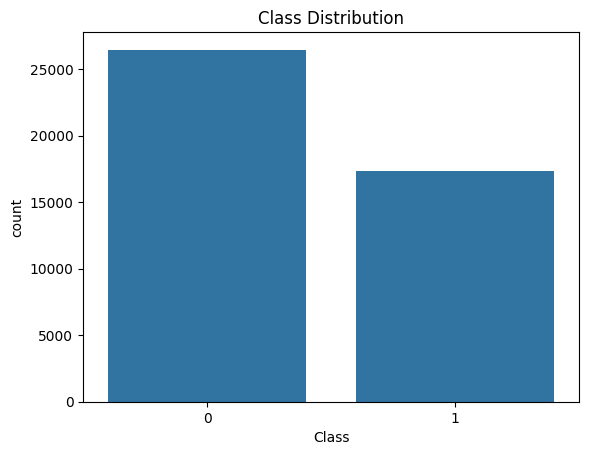

In [6]:
sns.countplot(x=train["Class"])
plt.title("Class Distribution")
plt.show()

## Feature and Target Separation

Features (X): F01–F47  
Target (y): Class

The model will learn relationships between the input features and the device state.

In [7]:
X = train.drop("Class", axis=1)
y = train["Class"]

## Feature Leakage Check

A correlation analysis was performed between each feature and the target variable.

No feature showed extremely high correlation (>0.9), indicating that the dataset does not contain obvious label leakage.

In [8]:
for col in X.columns:
    corr = np.corrcoef(train[col], train["Class"])[0,1]
    if abs(corr) > 0.9:
        print(col, corr)

## Train-Validation Split

The dataset is split into training and validation sets using **stratified sampling**.

This ensures that both sets maintain the same class distribution.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (35020, 47)
Validation: (8756, 47)


## Model Selection

XGBoost was selected because gradient boosting models are highly effective for structured tabular datasets.

The model uses multiple decision trees that sequentially correct previous errors, resulting in strong predictive performance.

In [10]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

## Model Evaluation

The model performance is evaluated using classification metrics and ROC-AUC.

The ROC-AUC score measures the model's ability to distinguish between normal and faulty device states.

In [11]:
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC Score:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5293
           1       0.99      0.97      0.98      3463

    accuracy                           0.98      8756
   macro avg       0.99      0.98      0.98      8756
weighted avg       0.98      0.98      0.98      8756

ROC AUC Score: 0.9988757019429549


## Cross Validation

To ensure model stability, **5-fold stratified cross validation** was performed.

The results demonstrate consistent ROC-AUC scores across folds, indicating strong generalization performance.

In [12]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_index, val_index in kf.split(X, y):

    X_tr, X_va = X.iloc[train_index], X.iloc[val_index]
    y_tr, y_va = y.iloc[train_index], y.iloc[val_index]

    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_va)[:,1]

    score = roc_auc_score(y_va, y_prob)

    scores.append(score)

print("Fold Scores:", scores)
print("Mean ROC AUC:", np.mean(scores))

Fold Scores: [np.float64(0.9985429625286537), np.float64(0.9985129089868648), np.float64(0.9983364226625904), np.float64(0.9982510172521112), np.float64(0.998415879709017)]
Mean ROC AUC: 0.9984118382278474


## Final Model Training

After validating the model performance, the classifier is retrained on the entire training dataset to utilize all available information before generating predictions for the test set.

In [13]:
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

## Submission File

The FINAL.csv file contains predictions for the test dataset.

Format:

ID, CLASS

The order of IDs matches the order in TEST.csv as required by the competition guidelines.

In [14]:
test_features = test.drop("ID", axis=1)

predictions = model.predict(test_features)

submission = pd.DataFrame({
    "ID": test["ID"],
    "CLASS": predictions
})

submission.to_csv("FINAL.csv", index=False)

print("Submission file created successfully.")

Submission file created successfully.
